In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("cold_chain_dataset.csv")

In [3]:
df.head()

,avg_temp,max_temp,min_temp,shock_count,max_accel,weight_loss,trip_duration,quality_score,risk_level
0,4.375147,5.044779,2.902204,21,3.833005,16.360996,246,0.000000,CRITICAL
1,6.010094,7.693829,4.578054,22,2.952237,6.613219,172,0.000000,CRITICAL
2,-1.961007,0.133411,-2.641508,4,1.468912,22.904824,82,55.927458,WARNING
3,-1.419702,0.391476,-3.033958,23,2.567412,3.744785,223,35.788002,CRITICAL
4,-0.240930,2.415425,-0.964200,6,3.670573,1.374732,146,64.730683,WARNING


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   avg_temp       2000 non-null   float64
 1   max_temp       2000 non-null   float64
 2   min_temp       2000 non-null   float64
 3   shock_count    2000 non-null   int64  
 4   max_accel      2000 non-null   float64
 5   weight_loss    2000 non-null   float64
 6   trip_duration  2000 non-null   int64  
 7   quality_score  2000 non-null   float64
 8   risk_level     2000 non-null   object 
dtypes: float64(6), int64(2), object(1)
memory usage: 140.8+ KB


In [5]:
df.describe()

,avg_temp,max_temp,min_temp,shock_count,max_accel,weight_loss,trip_duration,quality_score
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2.096183,3.580129,1.085673,14.798500,2.765906,14.856082,163.852500,26.260035
std,2.592488,2.757683,2.668832,8.773904,1.311845,8.652382,76.979807,23.851495
min,-1.991600,-1.942179,-3.910385,0.000000,0.500043,0.001071,30.000000,0.000000
25%,-0.109932,1.380524,-1.110327,7.000000,1.611930,7.402208,97.000000,2.169949
50%,2.005344,3.436636,0.981793,15.000000,2.800713,14.705135,165.500000,22.460370
75%,3.746650,5.476411,2.832014,22.000000,3.905121,22.119201,230.000000,42.851324
max,7.988027,10.822395,7.916252,30.000000,4.996763,29.997235,300.000000,100.000000


In [6]:
df.isnull().sum()

,0
avg_temp,0
max_temp,0
min_temp,0
shock_count,0
max_accel,0
weight_loss,0
trip_duration,0
quality_score,0
risk_level,0


**Data Cleaning & Validation**

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df[(df['max_temp'] < df['min_temp'])]

,avg_temp,max_temp,min_temp,shock_count,max_accel,weight_loss,trip_duration,quality_score,risk_level


In [9]:
df[(df['shock_count'] < 0) | (df['weight_loss'] < 0)]

,avg_temp,max_temp,min_temp,shock_count,max_accel,weight_loss,trip_duration,quality_score,risk_level


In [10]:
df.describe()

,avg_temp,max_temp,min_temp,shock_count,max_accel,weight_loss,trip_duration,quality_score
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2.096183,3.580129,1.085673,14.798500,2.765906,14.856082,163.852500,26.260035
std,2.592488,2.757683,2.668832,8.773904,1.311845,8.652382,76.979807,23.851495
min,-1.991600,-1.942179,-3.910385,0.000000,0.500043,0.001071,30.000000,0.000000
25%,-0.109932,1.380524,-1.110327,7.000000,1.611930,7.402208,97.000000,2.169949
50%,2.005344,3.436636,0.981793,15.000000,2.800713,14.705135,165.500000,22.460370
75%,3.746650,5.476411,2.832014,22.000000,3.905121,22.119201,230.000000,42.851324
max,7.988027,10.822395,7.916252,30.000000,4.996763,29.997235,300.000000,100.000000


In [11]:
# Limit extreme values (clipping)
df['max_temp'] = df['max_temp'].clip(-2, 10)
df['min_temp'] = df['min_temp'].clip(-5, 8)
df['shock_count'] = df['shock_count'].clip(0, 50)
df['weight_loss'] = df['weight_loss'].clip(0, 40)
df['trip_duration'] = df['trip_duration'].clip(30, 300)

In [12]:
df.describe()

,avg_temp,max_temp,min_temp,shock_count,max_accel,weight_loss,trip_duration,quality_score
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2.096183,3.577595,1.085673,14.798500,2.765906,14.856082,163.852500,26.260035
std,2.592488,2.751565,2.668832,8.773904,1.311845,8.652382,76.979807,23.851495
min,-1.991600,-1.942179,-3.910385,0.000000,0.500043,0.001071,30.000000,0.000000
25%,-0.109932,1.380524,-1.110327,7.000000,1.611930,7.402208,97.000000,2.169949
50%,2.005344,3.436636,0.981793,15.000000,2.800713,14.705135,165.500000,22.460370
75%,3.746650,5.476411,2.832014,22.000000,3.905121,22.119201,230.000000,42.851324
max,7.988027,10.000000,7.916252,30.000000,4.996763,29.997235,300.000000,100.000000


In [13]:
import matplotlib.pyplot as plt

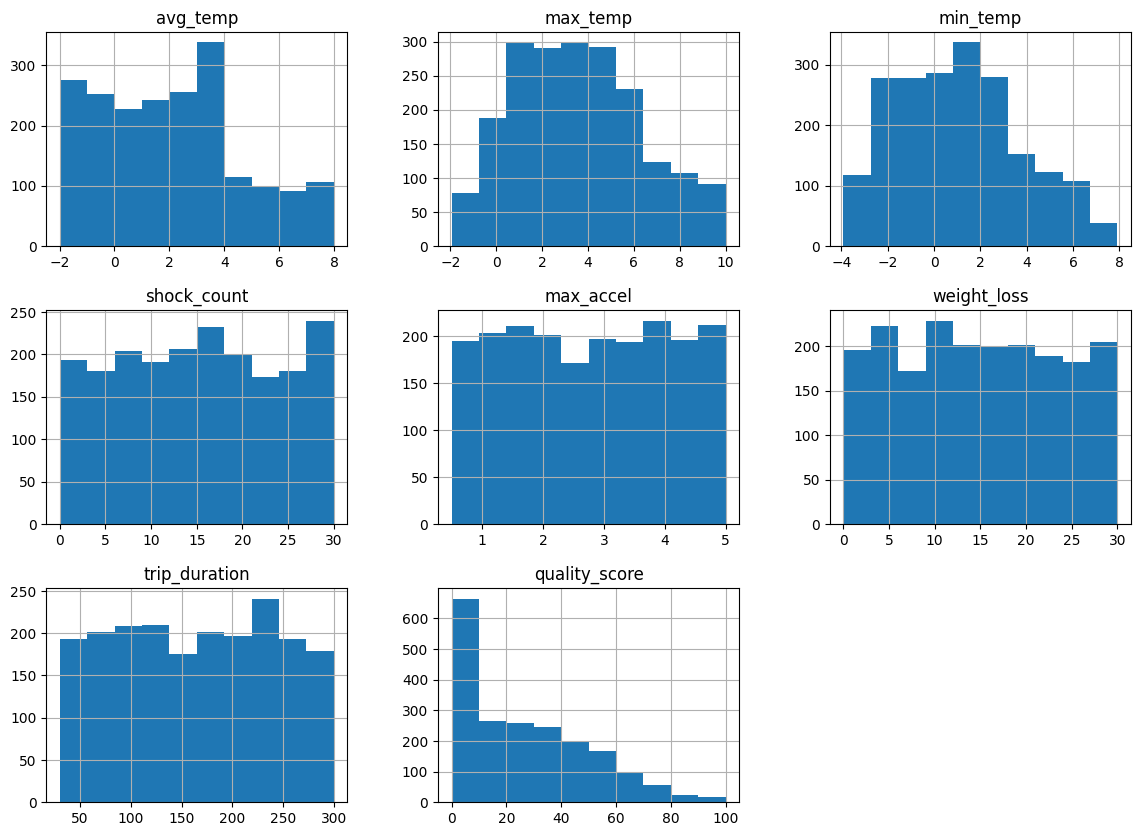

In [14]:
df.hist(figsize=(14,10))
plt.show()

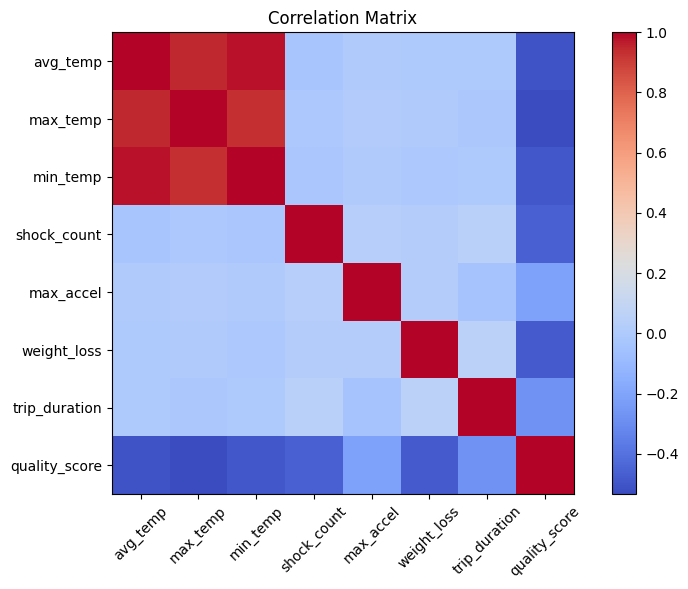

In [15]:
corr = df.corr(numeric_only=True)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

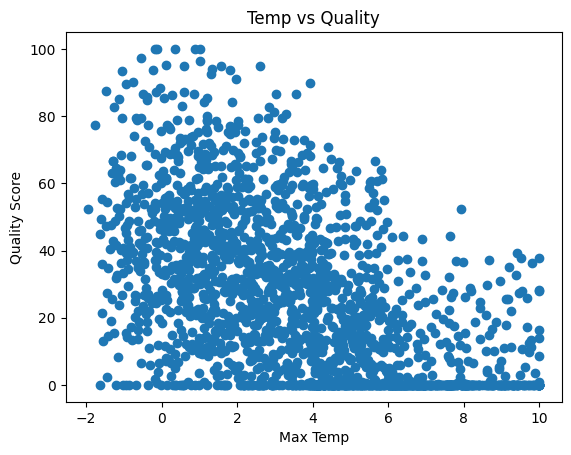

In [16]:
plt.scatter(df['max_temp'], df['quality_score'])
plt.xlabel("Max Temp")
plt.ylabel("Quality Score")
plt.title("Temp vs Quality")
plt.show()

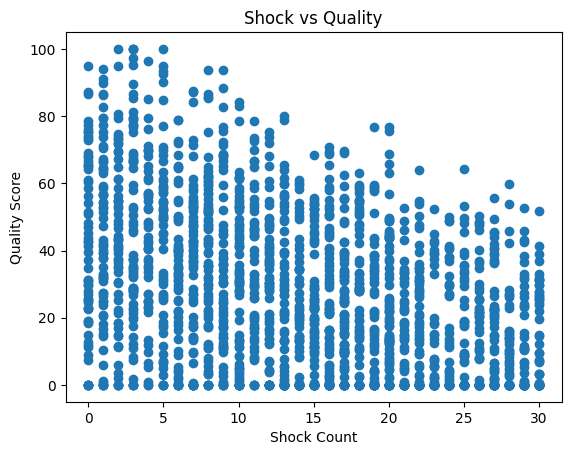

In [17]:
plt.scatter(df['shock_count'], df['quality_score'])
plt.xlabel("Shock Count")
plt.ylabel("Quality Score")
plt.title("Shock vs Quality")
plt.show()

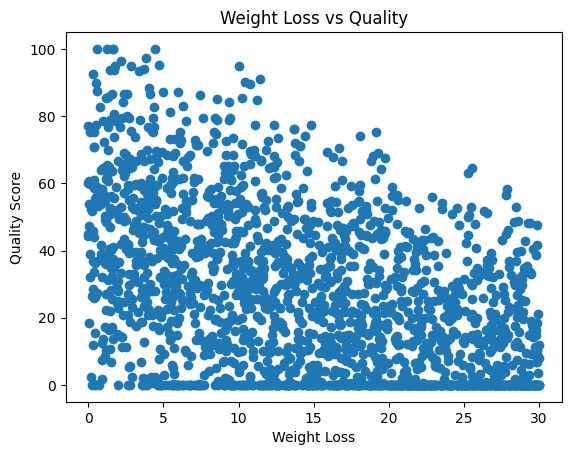

In [18]:
plt.scatter(df['weight_loss'], df['quality_score'])
plt.xlabel("Weight Loss")
plt.ylabel("Quality Score")
plt.title("Weight Loss vs Quality")
plt.show()

In [19]:
df['risk_level'].value_counts()

,count
risk_level,
CRITICAL,1634
WARNING,325
SAFE,41


In [20]:
# Temperature variation (important for stability)
df["temp_range"] = df["max_temp"] - df["min_temp"]

# Weight loss ratio (normalized)
df["loss_ratio"] = df["weight_loss"] / 30

# Shock intensity feature
df["shock_intensity"] = df["shock_count"] * df["max_accel"]

# Temperature severity flag
df["high_temp_flag"] = (df["max_temp"] > 5).astype(int)

In [21]:
df.head()

,avg_temp,max_temp,min_temp,shock_count,max_accel,weight_loss,trip_duration,quality_score,risk_level,temp_range,loss_ratio,shock_intensity,high_temp_flag
0,4.375147,5.044779,2.902204,21,3.833005,16.360996,246,0.000000,CRITICAL,2.142575,0.545367,80.493102,1
1,6.010094,7.693829,4.578054,22,2.952237,6.613219,172,0.000000,CRITICAL,3.115774,0.220441,64.949207,1
2,-1.961007,0.133411,-2.641508,4,1.468912,22.904824,82,55.927458,WARNING,2.774919,0.763494,5.875648,0
3,-1.419702,0.391476,-3.033958,23,2.567412,3.744785,223,35.788002,CRITICAL,3.425435,0.124826,59.050475,0
4,-0.240930,2.415425,-0.964200,6,3.670573,1.374732,146,64.730683,WARNING,3.379625,0.045824,22.023440,0


In [22]:
y = df["quality_score"]

In [23]:
X = df.drop(["quality_score", "risk_level"], axis=1)

In [24]:
X.columns

Index(['avg_temp', 'max_temp', 'min_temp', 'shock_count', 'max_accel',
       'weight_loss', 'trip_duration', 'temp_range', 'loss_ratio',
       'shock_intensity', 'high_temp_flag'],
      dtype='object')

In [25]:
import pandas as pd

pd.Series(X.columns)

,0
0,avg_temp
1,max_temp
2,min_temp
3,shock_count
4,max_accel
5,weight_loss
6,trip_duration
7,temp_range
8,loss_ratio
9,shock_intensity


In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42     # ensures same split every time
)

In [28]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1600, 11)
Testing set: (400, 11)


In [29]:
from sklearn.ensemble import RandomForestRegressor

In [30]:
model = RandomForestRegressor(
    n_estimators=100,   # number of trees
    max_depth=10,       # controls complexity
    random_state=42
)

In [31]:
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, random_state=42)

In [32]:
y_pred = model.predict(X_test)

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [34]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 5.000986745526105
RMSE: 6.537727371054379
R2 Score: 0.9185108424056583


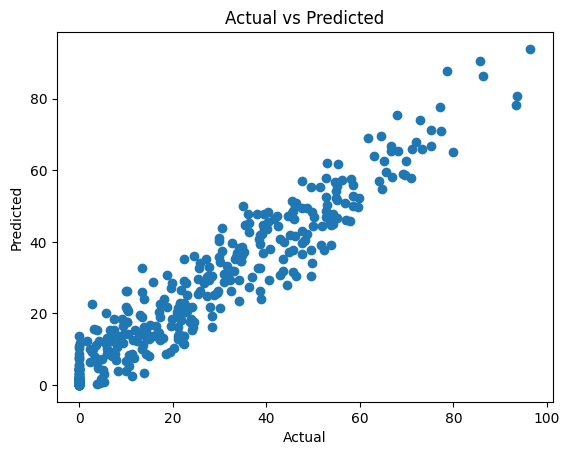

In [35]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

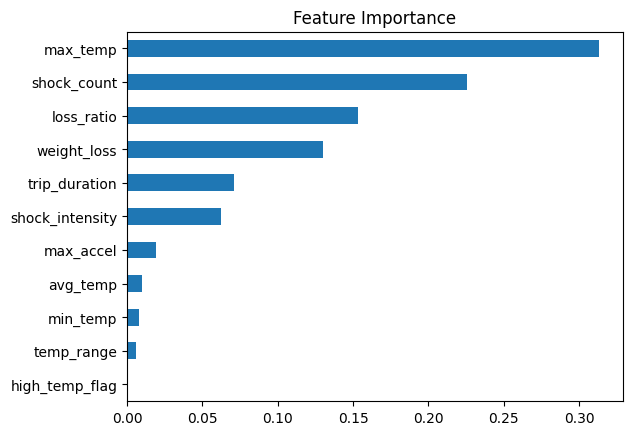

In [36]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [37]:
import joblib

joblib.dump(model, "cold_chain_model.pkl")

['cold_chain_model.pkl']

In [38]:
from google.colab import files
files.download("cold_chain_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>